In [1]:
import pandas as pd
import numpy as np
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import LabelEncoder,QuantileTransformer
from sklearn.model_selection import train_test_split

In [3]:
class Trainer:

    def __init__(self):
        self.seed = 42
        self.data_path = r"data/cicids_cleaned_resampled.csv"
        self.df = None
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.quantile_transformer = QuantileTransformer(n_quantiles=10**4, output_distribution='uniform')
        self.le = LabelEncoder()
        self.model = None
        self.ROOT = r"{}"

    def data_loader(self):
        self.df = pd.read_csv(self.data_path)
        # print(f"Loading Data Of {len(self.df.columns)-1} Features")
        print(f"Number Of Samples:{len(self.df)}")


    def data_preprocess(self,insignificant_features=[]):

        drop_cols = ['id','Flow ID','Src IP','Src Port','Dst IP','Dst Port','Protocol','Timestamp','Attempted Category']
        self.df.drop(columns=drop_cols,inplace=True,errors='ignore')

        if insignificant_features:
            self.df.drop(columns=insignificant_features,inplace=True)
        
        X,y = self.df.drop(columns=['Label']),self.le.fit_transform(self.df['Label']).astype(np.int64)
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=self.seed)
        
        features = X.columns.to_list()

        X_train_scaled = self.quantile_transformer.fit_transform(X_train).astype(np.float32)
        X_test_scaled = self.quantile_transformer.transform(X_test).astype(np.float32)

        

        print(f"[Pre-processing]:Number Of Features:{len(self.df.columns)-1}")
        print("Total Number Of Samples:",len(X_train_scaled)+len(X_test_scaled))
        del self.df
        return X_train_scaled,y_train,X_test_scaled,y_test,features


    def hyper_param_tuning(self,in_features=16):

        scheduler_ElR = torch.optim.lr_scheduler.ExponentialLR
        scheduler_params_ElR_loss = {'gamma': 0.9}  

        params = {
                    'n_d':in_features,'n_a':in_features,'n_steps':5,
                    'n_shared':2,'n_independent':2,
                    'gamma':1.85,'lambda_sparse':1e-3,'clip_value':2,
                    'optimizer_fn':torch.optim.Adam,'momentum':0.02,
                    'optimizer_params':{'lr':1e-2},'verbose':1,
                    'seed':self.seed,'device_name':self.device,
                    'mask_type':'sparsemax','scheduler_fn':scheduler_ElR,'scheduler_params': scheduler_params_ElR_loss
        }

        return params
    
    def invoke_model(self,params=None):
        
        if not params:
            return "Please Pass Params"
        
        self.model = TabNetClassifier(
            **params
        )

        return self.model

    

    def train(self,X_train,y_train,X_test,y_test):
        train_params = {
                'X_train':X_train,'y_train':y_train,
                'eval_set':[(X_test,y_test)],'patience':15,'max_epochs':100,
                'eval_metric':['accuracy'],'eval_name':['Validation'],
                'compute_importance':True,'batch_size':2056,'virtual_batch_size':512,
                'drop_last':False,'warm_start':False,'num_workers':2,'pin_memory':True,
        }

        self.model.fit(**train_params)

        return self.model


    def evaluate(self):
        pass

    def save(self):
        pass


    def feature_importance(self,model=None,features=None):
        model = model if model else self.model
        feature_importance = model.feature_importances_
        feature_df = pd.DataFrame({'Features':features,'Importance':feature_importance})
        feature_df.sort_values(by='Importance',ascending=False,inplace=True)
        return feature_df
        

    def invoke_pipeline(self):
        self.data_loader()
        X_train_scaled,y_train,X_test,y_test,features = self.data_preprocess()
    


In [14]:
trainer = Trainer()
trainer.data_loader()
X_train_scaled,y_train,X_test,y_test,features = trainer.data_preprocess()

params = trainer.hyper_param_tuning(in_features=len(features))
model = trainer.invoke_model(params=params)
model = trainer.train(X_train=X_train_scaled,y_train=y_train,X_test=X_test,y_test=y_test)


feature_importance = trainer.feature_importance(model=model,features=features)


Number Of Samples:799928
[Pre-processing]:Number Of Features:81
Total Number Of Samples: 799928


/home/abdulrahimfami/Desktop/final_poject/myenv/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.21324 | Validation_accuracy: 0.95925 | Validation_logloss: 0.09776 |  0:00:12s
epoch 1  | loss: 0.08177 | Validation_accuracy: 0.91005 | Validation_logloss: 0.37003 |  0:00:24s
epoch 2  | loss: 0.078   | Validation_accuracy: 0.96032 | Validation_logloss: 0.09492 |  0:00:37s
epoch 3  | loss: 0.06854 | Validation_accuracy: 0.97788 | Validation_logloss: 0.05663 |  0:00:49s
epoch 4  | loss: 0.05536 | Validation_accuracy: 0.979   | Validation_logloss: 0.05468 |  0:01:01s
epoch 5  | loss: 0.05384 | Validation_accuracy: 0.97782 | Validation_logloss: 0.057   |  0:01:13s
epoch 6  | loss: 0.05141 | Validation_accuracy: 0.9645  | Validation_logloss: 0.0876  |  0:01:25s
epoch 7  | loss: 0.04997 | Validation_accuracy: 0.98006 | Validation_logloss: 0.04903 |  0:01:38s
epoch 8  | loss: 0.04914 | Validation_accuracy: 0.98024 | Validation_logloss: 0.04853 |  0:01:50s
epoch 9  | loss: 0.04799 | Validation_accuracy: 0.9811  | Validation_logloss: 0.04462 |  0:02:03s
epoch 10 | loss: 0.0

/home/abdulrahimfami/Desktop/final_poject/myenv/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [21]:
def retreive_insignificant_features(feature_importance,threshold = 0.01):
    insignificant_features = feature_importance[feature_importance['Importance'] < threshold]['Features'].tolist()
    return insignificant_features

In [23]:
insignificant_features = retreive_insignificant_features(feature_importance=feature_importance)


### Classifier2

In [ ]:
trainer2 = Trainer()
trainer2.data_loader()
X_train_scaled,y_train,X_test,y_test,features = trainer2.data_preprocess(insignificant_features=insignificant_features)

params = trainer2.hyper_param_tuning(in_features=len(features))
model2 = trainer2.invoke_model(params=params)
model2 = trainer2.train(X_train=X_train_scaled,y_train=y_train,X_test=X_test,y_test=y_test)


feature_importance = trainer2.feature_importance(model=model2,features=features)


Number Of Samples:799928
[Pre-processing]:Number Of Features:27
Total Number Of Samples: 799928


/home/abdulrahimfami/Desktop/final_poject/myenv/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.2177  | Validation_accuracy: 0.9607  |  0:00:11s
epoch 1  | loss: 0.08174 | Validation_accuracy: 0.97261 |  0:00:22s
epoch 2  | loss: 0.07244 | Validation_accuracy: 0.97314 |  0:00:33s
epoch 3  | loss: 0.07227 | Validation_accuracy: 0.97472 |  0:00:44s
epoch 4  | loss: 0.07113 | Validation_accuracy: 0.96772 |  0:00:55s
epoch 5  | loss: 0.06945 | Validation_accuracy: 0.97787 |  0:01:06s
epoch 6  | loss: 0.06057 | Validation_accuracy: 0.97822 |  0:01:17s
epoch 7  | loss: 0.06633 | Validation_accuracy: 0.97799 |  0:01:29s
epoch 8  | loss: 0.05546 | Validation_accuracy: 0.97985 |  0:01:40s
epoch 9  | loss: 0.04905 | Validation_accuracy: 0.98105 |  0:01:51s
epoch 10 | loss: 0.04896 | Validation_accuracy: 0.98069 |  0:02:03s
epoch 11 | loss: 0.04896 | Validation_accuracy: 0.9808  |  0:02:14s
epoch 12 | loss: 0.04702 | Validation_accuracy: 0.98139 |  0:02:25s
epoch 13 | loss: 0.04881 | Validation_accuracy: 0.98015 |  0:02:37s
epoch 14 | loss: 0.04734 | Validation_accuracy: 

/home/abdulrahimfami/Desktop/final_poject/myenv/lib/python3.10/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


ValueError: All arrays must be of the same length

In [35]:
feature_importance = trainer2.feature_importance(model=model2,features=features)


In [37]:
import os

folder = "detection"
os.makedirs(folder, exist_ok=True)


# Save TabNet model
model2.save_model(os.path.join(folder, "tabnet_model"))

import pickle

# Save LabelEncoder
with open(os.path.join(folder, "label_encoder.pkl"), "wb") as f:
    pickle.dump(trainer2.le, f)

# Save QuantileTransformer
with open(os.path.join(folder, "quantile_transformer.pkl"), "wb") as f:
    pickle.dump(trainer2.quantile_transformer, f)

Successfully saved model at detection/tabnet_model.zip


In [38]:
sample = X_test[0].reshape(1, -1) 

In [41]:
mask, G = model2.explain(sample)

In [43]:
# Take a sample (first row from test set)
sample = X_test[0].reshape(1, -1)  # shape (1, num_features)

# Get TabNet explanation
explain_matrix, _ = model2.explain(sample)  # explain_matrix shape: (1, num_features)

# Map each feature to its contribution
feature_scores = [
    (feat, score) 
    for feat, score in zip(features, explain_matrix[0])  # use your feature list
    if score > 0
]

# Sort by contribution descending
feature_scores.sort(key=lambda x: x[1], reverse=True)

# Convert to percentages
total = sum(score for _, score in feature_scores)
percentage_scores = [(name, (score / total) * 100) for name, score in feature_scores]

# Format as text
top_features_text = "\n".join(
    [f"  • {name}: {pct:.5f}%" for name, pct in percentage_scores]
)

print("Top contributing features for this sample:")
print(top_features_text)

Top contributing features for this sample:
  • FWD Init Win Bytes: 36.68317%
  • Fwd Act Data Pkts: 27.22818%
  • Bwd Header Length: 13.79074%
  • Bwd Packet Length Std: 12.20413%
  • Bwd IAT Mean: 10.09379%


In [45]:
import numpy as np
import pandas as pd

def explain_one_sample_per_class(model, X_scaled, y_true, feature_names):
    """
    Take one sample per unique class in y_true, predict it, and explain contributions.
    """
    explanations = []
    unique_classes = np.unique(y_true)
    
    for cls in unique_classes:
        # Take first sample of this class
        idx = np.where(y_true == cls)[0][0]
        sample = X_scaled[idx].reshape(1, -1)
        
        # Predict
        y_pred = model.predict(sample)[0]
        
        # Explain
        explain_matrix, _ = model.explain(sample)
        sample_features = explain_matrix[0]
        
        # Keep positive contributions
        feature_scores = [
            (feat, score) for feat, score in zip(feature_names, sample_features) if score > 0
        ]
        feature_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Compute percentage contributions
        total = sum(score for _, score in feature_scores) if feature_scores else 1
        percentage_scores = [(name, (score / total) * 100) for name, score in feature_scores]
        
        # Format text
        top_features_text = "\n".join(
            [f"  • {name}: {pct:.5f}%" for name, pct in percentage_scores]
        )
        
        sample_text = (
            f"Class {cls} | Predicted class: {y_pred}\n"
            f"Top contributing features:\n{top_features_text}\n"
            f"{'-'*50}"
        )
        
        explanations.append(sample_text)
    
    return explanations

# Your feature list: features (27 pruned features)
sample_explanations = explain_one_sample_per_class(model2, X_test, y_test, features)

# Print all class sample explanations
for explanation in sample_explanations:
    print(explanation)

Class 0 | Predicted class: 0
Top contributing features:
  • FWD Init Win Bytes: 36.68317%
  • Fwd Act Data Pkts: 27.22818%
  • Bwd Header Length: 13.79074%
  • Bwd Packet Length Std: 12.20413%
  • Bwd IAT Mean: 10.09379%
--------------------------------------------------
Class 1 | Predicted class: 1
Top contributing features:
  • PSH Flag Count: 29.99505%
  • Fwd Seg Size Min: 19.12639%
  • FWD Init Win Bytes: 17.97469%
  • Bwd IAT Mean: 17.89102%
  • Subflow Fwd Bytes: 7.69508%
  • Total Bwd packets: 4.16182%
  • Subflow Bwd Bytes: 3.15594%
--------------------------------------------------
Class 2 | Predicted class: 2
Top contributing features:
  • Bwd Header Length: 37.10428%
  • Fwd Act Data Pkts: 20.61473%
  • Fwd Packets/s: 16.35207%
  • FWD Init Win Bytes: 12.11841%
  • Average Packet Size: 8.44788%
  • Bwd IAT Mean: 3.98381%
  • Bwd Segment Size Avg: 1.37882%
--------------------------------------------------
Class 3 | Predicted class: 3
Top contributing features:
  • Bwd Packe

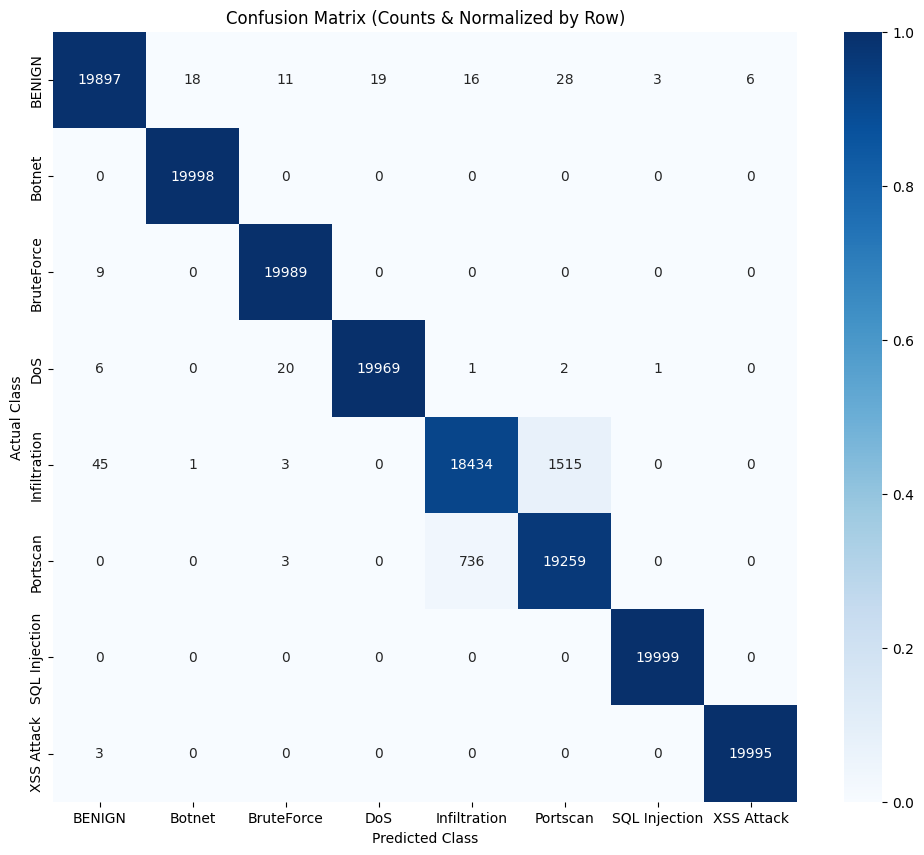

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict on test set
y_pred = model2.predict(X_test)  # make sure you use scaled features

# Decode the labels to original class names
y_test_labels = trainer.le.inverse_transform(y_test)
y_pred_labels = trainer.le.inverse_transform(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=trainer.le.classes_)

# Normalize to percentages per class
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(12,10))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap="Blues",
            xticklabels=trainer.le.classes_, yticklabels=trainer.le.classes_)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix (Counts & Normalized by Row)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Predict on test set
y_pred = model2.predict(X_test)

# Decode numeric labels to original class names
y_test_labels = trainer.le.inverse_transform(y_test)
y_pred_labels = trainer.le.inverse_transform(y_pred)

# Generate classification report
report = classification_report(y_test_labels, y_pred_labels, digits=4)
print("Classification Report:\n")
print(report)

Classification Report:

               precision    recall  f1-score   support

       BENIGN     0.9968    0.9949    0.9959     19998
       Botnet     0.9991    1.0000    0.9995     19998
   BruteForce     0.9982    0.9995    0.9989     19998
          DoS     0.9990    0.9985    0.9988     19999
 Infiltration     0.9608    0.9218    0.9409     19998
     Portscan     0.9257    0.9630    0.9440     19998
SQL Injection     0.9998    1.0000    0.9999     19999
   XSS Attack     0.9997    0.9998    0.9998     19998

     accuracy                         0.9847    159986
    macro avg     0.9849    0.9847    0.9847    159986
 weighted avg     0.9849    0.9847    0.9847    159986



In [ ]:
# params = {
#     'n_d': in_features + 10,
#     'n_a': in_features + 10,
#     'n_steps': 6,
#     'n_shared': 2,
#     'n_independent': 2,
#     'gamma': 1.9,
#     'lambda_sparse': 5e-4,
#     'clip_value': 2,
#     'optimizer_fn': torch.optim.Adam,
#     'momentum': 0.02,
#     'optimizer_params': {'lr': 5e-3},
#     'verbose': 1,
#     'seed': self.seed,
#     'device_name': self.device,
#     'mask_type': 'sparsemax',
#     'scheduler_fn': scheduler_ElR,
#     'scheduler_params': scheduler_params_ElR_loss
# }

In [1]:
feature_list  = ['Total Bwd packets',
 'Fwd Packet Length Min',
 'Fwd Packet Length Std',
 'Bwd Packet Length Max',
 'Bwd Packet Length Std',
 'Flow IAT Std',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd Header Length',
 'Fwd Packets/s',
 'Packet Length Min',
 'Packet Length Variance',
 'FIN Flag Count',
 'PSH Flag Count',
 'Average Packet Size',
 'Fwd Segment Size Avg',
 'Bwd Segment Size Avg',
 'Subflow Fwd Bytes',
 'Subflow Bwd Bytes',
 'FWD Init Win Bytes',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Max',
 'Total TCP Flow Time']

In [ ]:
X,y = df.drop(columns=['Label']),self.le.fit_transform(df['Label']).astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=self.seed)

features = X.columns.to_list()

X_train_scaled = quantile_transformer.fit_transform(X_train).astype(np.float32)
X_test_scaled = quantile_transformer.transform(X_test).astype(np.float32)



print(f"[Pre-processing]:Number Of Features:{len(df.columns)-1}")
print("Total Number Of Samples:",len(X_train_scaled)+len(X_test_scaled))

In [12]:
trainer2 = Trainer()
trainer2.data_loader()


Number Of Samples:799928


In [13]:
le = LabelEncoder()
X,y = trainer2.df.drop(columns=['Label']),le.fit_transform(trainer2.df['Label']).astype(np.int64)


In [16]:
X = X[feature_list]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [19]:
model = TabNetClassifier(device_name='cuda')

/home/abdulrahimfami/Desktop/final_poject/myenv/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [20]:
model.load_model(r"models/Detector/tabnet_model.zip")

/home/abdulrahimfami/Desktop/final_poject/myenv/lib/python3.10/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [26]:
import pickle


with open("models/Detector/quantile_transformer.pkl", "rb") as f:
    qt = pickle.load(f)

In [27]:
X_test_scaled = qt.transform(X_test)

In [22]:
model

,n_d,27
,n_a,27
,n_steps,5
,gamma,1.85
,cat_idxs,[]
,cat_dims,[]
,cat_emb_dim,[]
,n_independent,2
,n_shared,2
,epsilon,1e-15
,momentum,0.02


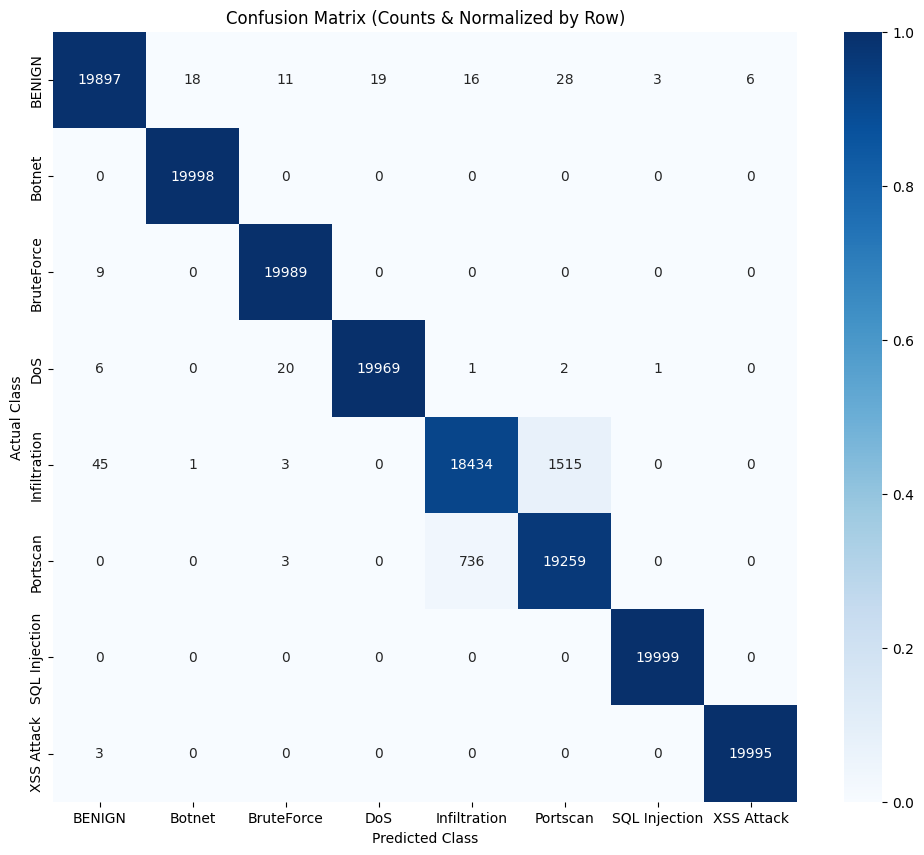

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict on test set
y_pred = model.predict(X_test_scaled)  # make sure you use scaled features

# Decode the labels to original class names
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred)

# Compute confusion matrix
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)

# Normalize to percentages per class
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
plt.figure(figsize=(12,10))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix (Counts & Normalized by Row)")
plt.show()